In [ ]:
# PCA approach
'''
PCA is used for finding good representation for given dataset
    representing the original dataset with the help of the eigen vectors
'''
import pandas as pd

df = pd.read_csv("tests/test_data.csv")
df.head()

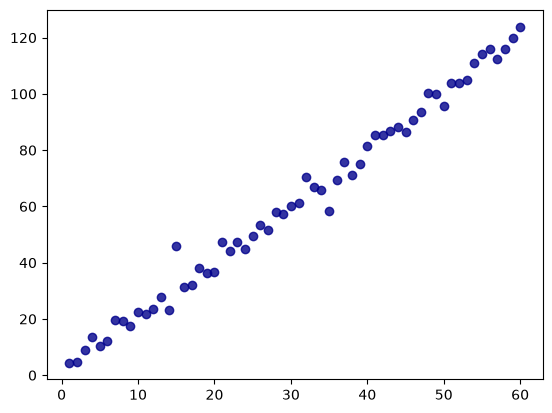

In [19]:
# Making visualization for given dataset
import matplotlib.pyplot as plt 

X = df["X"]
y = df["y"]

plt.scatter(X, y, alpha=0.8, color='darkblue')
plt.show()


In [31]:
# PCA CORE
'''
Principle Components Analysis
Given some vector which represent the most variances of dataset
critical vectors directions are represented with pca

implementation way
1. mean centerization is must ->  covariance matrix
2. eigen values, and eigen vector pairs
3. Finally eigen vectors listing with greatest eigen values respectives

Q : how to interpret the given eigen vectors which we get with k top vectors
    Project data vectors into the given top rankers ?
        What if we represented the datset with just top 2 vectors from the listing ? 

1:19 | 14 Aug | partial implementation for pca
testing, documenting and visualization requried
    Also node connection pondering thoughts are also required
        for the ultimate integration into main code base and ideology of preprocessing dataset winth pca and its implementation scopes and usage around the yantragya
'''
import numpy as np

def pca(X, n_components):
    X_centered = X - np.mean(X, axis=0)
    # Not clear about rowvar
    cov_matrix = np.cov(X_centered, rowvar=False)

    e_values, e_vectors = np.linalg.eigh(cov_matrix)
    sorted_index = np.argsort(e_values)[::-1] # sorted eigen_values, revered the indexing
    sorted_eignvalues = e_values[sorted_index] # arg_sort : sorting indices for extraction
    sorted_eigenvectors = e_vectors[:, sorted_index]

    top_n_component = sorted_eigenvectors[:, 0:n_components]
    X_reduced = np.dot(X_centered, top_n_component)
    return X_reduced, sorted_eigenvectors, sorted_eignvalues

reduced, e_vectors, e_values = pca([X,y],2)
print(f"Given reduced representations : {reduced}, {e_vectors}, {e_values}")

Given reduced representations : [[-1.37889225e+02  1.10401396e-14]
 [ 1.37889225e+02 -5.48902452e-15]], [[ 1.26550860e-02 -1.72138232e-03 -8.99518291e-03 ...  0.00000000e+00
   2.46659336e-05  5.58936842e-04]
 [ 9.39159677e-03  2.03468828e-01  6.61884328e-01 ...  8.82770030e-02
  -6.82183703e-02 -1.65903178e-01]
 [ 2.15390289e-02 -7.81058900e-02 -2.16101681e-01 ... -1.83783967e-01
   4.34165246e-02 -1.39508928e-01]
 ...
 [ 2.10567577e-01  4.05035502e-03 -9.43729161e-02 ...  1.67374642e-01
  -6.40685668e-02 -9.80133466e-02]
 [ 2.21155786e-01 -4.90004652e-02  3.05602013e-01 ... -2.20695044e-01
   1.10817342e-01 -2.86372113e-02]
 [ 2.31816518e-01  2.96187313e-02 -1.11624731e-01 ... -8.95379218e-02
  -5.01983054e-02 -9.14218150e-02]], [ 3.80268767e+04  9.74339681e-12  8.56314958e-12  7.10916488e-12
  7.08278077e-12  5.71876137e-12  4.97027596e-12  4.65479472e-12
  4.64642036e-12  4.22217249e-12  3.84239868e-12  3.52122274e-12
  2.82032563e-12  2.73741081e-12  2.56069625e-12  1.97701010e-12